# Laboratorio S07: Dashboard Interactivo con ipywidgets - Churn

**Objetivo:** Construir un prototipo interactivo para analizar Churn usando `interact` de ipywidgets.

**Equipo:**
- Estudiante A: Sergio Sullcaray
- Estudiante B: _________________

**Instrucciones:** Sigan los pasos indicados en la guía `s07_lab.pdf`. Completen las celdas marcadas con `# TODO` y respondan las preguntas de reflexión.

## Paso 1: Cargar y explorar el dataset

El dataset se descarga automáticamente desde el repositorio oficial de IBM en GitHub.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
# TODO: Cargar el dataset de Churn directamente desde internet
# Hint: usar pd.read_csv() con la URL del repositorio de IBM
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# TODO: Convertir TotalCharges a numérico y eliminar nulos
# Hint: pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

# TODO: Crear columna binaria Churn_bin (1 si Churn=='Yes', 0 si no)
df["Churn_bin"] = (df["Churn"] == "Yes").astype(int)

print(f"Registros: {len(df)}")
print(f"Tasa de churn: {df['Churn_bin'].mean():.2%}")
df.head()

Registros: 7043
Tasa de churn: 26.54%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df["Churn_bin"].mean()

np.float64(0.2653698707936959)

**Pregunta de reflexión:** ¿Qué porcentaje de clientes abandonaron? ¿Esto indica un dataset balanceado o desbalanceado?

_Respuesta:26.53%

## Paso 2: Entrenar un modelo base

Entrenaremos una regresión logística simple para obtener probabilidades de churn.

In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [10]:
# TODO: Seleccionar features numéricas
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features]
y = df['Churn_bin']

# TODO: Dividir en train/test (70/30, stratify por y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

y_proba = modelo.predict_proba(X_test)[:, 1]

print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

Muestras de entrenamiento: 4930
Muestras de prueba: 2113


**Pregunta de reflexión:** ¿Por qué usamos `predict_proba` en lugar de `predict`? ¿Cómo se relaciona con el umbral de decisión?

_Respuesta:Porque da probabilidades  se relaciona al umbral porque dependiendo de este es una clase u otra.

## Paso 3: Definir la función de KPIs

Crearemos una función que calcule el F1 Score y el Business Value dado un umbral.

In [15]:
def calcular_kpis(umbral, costo_retencion=50, ingreso_mensual=65):
    """Calcula F1 y Business Value dado un umbral de decisión."""
    # TODO: Generar predicciones binarias usando el umbral
    # Hint: y_pred = (y_proba >= umbral).astype(int)
    y_pred = (y_proba >= umbral).astype(int)

    # TODO: Calcular F1 Score
    # Hint: f1_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # TODO: Obtener la matriz de confusión
    # Hint: tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # TODO: Calcular Business Value
    ingresos_retenidos = tp * ingreso_mensual * 12  # ingreso anual retenido
    costos = (tp + fp) * costo_retencion           # costo de campaña
    ingreso_perdido = fn * ingreso_mensual * 12     # clientes perdidos
    business_value = ingresos_retenidos - costos - ingreso_perdido

    return {
        'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'business_value': business_value,
        'ingresos_retenidos': ingresos_retenidos,
        'costos': costos, 'ingreso_perdido': ingreso_perdido
    }

# Prueba rápida
resultado = calcular_kpis(0.9)
print(f"F1: {resultado['f1']:.3f}")
print(f"Business Value: ${resultado['business_value']:,.0f}")

F1: 0.000
Business Value: $-437,580


**Pregunta de reflexión:** ¿Qué sucede con el F1 cuando el umbral es muy bajo (0.1)? ¿Y cuando es muy alto (0.9)?

_Respuesta:Cuando es muy alto se hace muy pequeño, en este caso 0

## Paso 4: Crear el semáforo y velocímetro

Crearemos funciones de visualización para los KPIs.

In [16]:
def semaforo_f1(f1_valor):
    """Genera un semáforo HTML basado en el F1 Score."""
    # TODO: Definir los colores según el valor de F1
    # Si F1 >= 0.7: verde activo (BUENO)
    # Si F1 >= 0.5: amarillo activo (REGULAR)
    # Si F1 < 0.5: rojo activo (BAJO)
    if f1_valor >= 0.7:
        color_r, color_a, color_v = '#ffcccc', '#ffffcc', '#00cc00'
        estado = 'BUENO'
    elif f1_valor >= 0.5:
        color_r, color_a, color_v = '#ffcccc', '#ffaa00', '#ccffcc'
        estado = 'REGULAR'
    else:
        color_r, color_a, color_v = '#cc0000', '#ffffcc', '#ccffcc'
        estado = 'BAJO'

    html = f"""
    <div style='text-align:center;'>
    <h3>F1 Score: {f1_valor:.3f} - {estado}</h3>
    <div style='display:inline-block; background:#333;
         border-radius:10px; padding:10px;'>
      <div style='width:30px;height:30px;border-radius:50%;
           background:{color_r}; margin:5px auto;'></div>
      <div style='width:30px;height:30px;border-radius:50%;
           background:{color_a}; margin:5px auto;'></div>
      <div style='width:30px;height:30px;border-radius:50%;
           background:{color_v}; margin:5px auto;'></div>
    </div></div>"""
    display(HTML(html))

# Prueba
semaforo_f1(0.65)

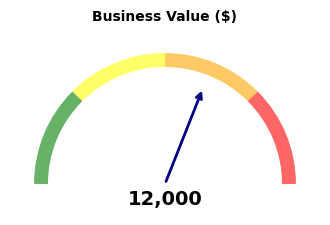

In [17]:
def dibujar_velocimetro(valor, titulo, vmin, vmax):
    """Dibuja un gauge semicircular con aguja."""
    fig, ax = plt.subplots(1, 1, figsize=(4, 2.5))
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.3, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')

    # Zonas de color
    colores = [('red', 0, 45), ('orange', 45, 90),
               ('yellow', 90, 135), ('green', 135, 180)]
    for color, start, end in colores:
        arco = patches.Arc((0, 0), 2.4, 2.4, angle=0,
                           theta1=start, theta2=end,
                           color=color, linewidth=10, alpha=0.6)
        ax.add_patch(arco)

    # TODO: Calcular el ángulo de la aguja
    # Hint: normalizar el valor entre 0 y 1, luego convertir a ángulo
    norm = (valor - vmin) / (vmax - vmin + 1e-9)
    norm = max(0, min(1, norm))
    angulo = np.pi * (1 - norm)

    # Dibujar aguja
    ax.annotate('', xy=(1.0 * np.cos(angulo), 1.0 * np.sin(angulo)),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='navy', lw=2))
    ax.text(0, -0.2, f'{valor:,.0f}', ha='center',
            fontsize=14, fontweight='bold')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    return fig

# Prueba
fig = dibujar_velocimetro(12000, 'Business Value ($)', -50000, 50000)
plt.show()

## Paso 5: Dashboard interactivo con `interact`

Ahora integraremos todo en una sola función con `@interact`.

**Referencia:** Revisa el slide "Controles con decorador @interact" en `slides07.tex`.

In [18]:
# TODO: Completar el decorador @interact con los rangos adecuados
# Hint: umbral de 0.1 a 0.9 con paso 0.05
#        costo_retencion de 10 a 200 con paso 10
#        ingreso_mensual de 20 a 150 con paso 5

@interact(umbral=(0.1 , 0.9 , 0.05),
          costo_retencion=(10 , 200 , 10),
          ingreso_mensual=(20 , 150 , 5))
def dashboard_churn(umbral=0.5, costo_retencion=50, ingreso_mensual=65):
    kpis = calcular_kpis(umbral, costo_retencion, ingreso_mensual)

    # Mostrar semáforo F1
    semaforo_f1(kpis['f1'])

    # Mostrar velocímetro Business Value
    fig = dibujar_velocimetro(
        kpis['business_value'], 'Business Value ($)',
        vmin=-50000, vmax=50000)
    plt.show()

    # Tabla resumen
    print(f"{'='*40}")
    print(f"  Umbral:           {umbral:.2f}")
    print(f"  TP: {kpis['tp']}  FP: {kpis['fp']}  "
          f"FN: {kpis['fn']}  TN: {kpis['tn']}")
    print(f"  Ingresos retenidos: ${kpis['ingresos_retenidos']:,.0f}")
    print(f"  Costos campaña:     ${kpis['costos']:,.0f}")
    print(f"  Ingreso perdido:    ${kpis['ingreso_perdido']:,.0f}")
    print(f"  BUSINESS VALUE:     ${kpis['business_value']:,.0f}")
    print(f"{'='*40}")

interactive(children=(FloatSlider(value=0.5, description='umbral', max=0.9, min=0.1, step=0.05), IntSlider(val…

**Pregunta de reflexión:** ¿Cuál es el umbral que maximiza el Business Value? ¿Coincide con el umbral que maximiza el F1 Score?

_Respuesta:_

## Paso 6: Hacer commit y push

Abran una terminal y ejecuten:

```bash
git add prototipo.ipynb
git commit -m "Paso 5: dashboard interactivo completo"
git push origin main
```

La pareja debe hacer `git pull` y verificar que el notebook funciona correctamente en su máquina.

## Paso 7 (Extensión): Agregar filtro por contrato

Intenten agregar un Dropdown para filtrar por tipo de contrato.

In [ ]:
# TODO: Extensión - Agregar un Dropdown de tipo de contrato
# Hint: Modificar la función para recibir un parámetro 'contrato'
#       y filtrar el dataset antes de entrenar el modelo
#       Opciones: 'Todos', 'Month-to-month', 'One year', 'Two year'

# COMPLETAR

## Pregunta abierta de negocio

Con un presupuesto de **$10,000 mensuales** para campañas de retención:

1. ¿Cuál sería el umbral óptimo para maximizar el Business Value dentro del presupuesto?
2. ¿Cómo cambiaría su estrategia si el costo de retención aumentara al doble?
3. ¿Es suficiente optimizar solo el F1 Score para tomar la mejor decisión de negocio?

_Respuestas:_